# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mkhlor006/Flyrank_internship_ML/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [17]:
!git clone https://github.com/mkhlor006/Flyrank_internship_ML.git

Cloning into 'Flyrank_internship_ML'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 162 (delta 68), reused 93 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 1.90 MiB | 13.58 MiB/s, done.
Resolving deltas: 100% (68/68), done.


In [18]:
import os
import numpy as np
import pandas as pd

# Make sure Colab is working inside the cloned GitHub repository.
repo_path = "/content/Flyrank_internship_ML"

if os.path.exists(repo_path):
    os.chdir(repo_path)

print("Current directory:")
print(os.getcwd())

Current directory:
/content/Flyrank_internship_ML


In [19]:
!python scripts/01_prepare_features.py

Prepared 30,000 rows from 30,000 raw rows
Wrote /content/Flyrank_internship_ML/data/processed/refresh_feature_vector.csv


In [20]:
!python scripts/02_baseline_score.py

Wrote baseline queue: /content/Flyrank_internship_ML/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340


In [21]:
import os

print(
    "Baseline file exists:",
    os.path.exists("data/processed/baseline_refresh_queue.csv")
)

Baseline file exists: True


In [22]:
data = pd.read_csv(
    "data/processed/refresh_feature_vector.csv"
)

print("Prepared data shape:", data.shape)
print("Clients:", data["client_id"].nunique())
print("Target counts:")
print(data["is_declining_label"].value_counts())

Prepared data shape: (30000, 52)
Clients: 32
Target counts:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



The playbook uses a ranked review queue to help a content team decide which pages to investigate first. The ranking is directional and is based on observed signals such as search visibility, search position, freshness risk and content opportunity.

The primary action is **REVIEW_FOR_REFRESH** for pages that show a measurable opportunity under the baseline rules. A second action is **MONITOR** when the available signals are not strong enough to prioritise a refresh review.

### Reason codes

- **VISIBLE_LOW_POSITION** — the page has meaningful observed search visibility but a relatively weak average position, so it may deserve investigation.
- **VISIBLE_POSITION_OPPORTUNITY** — the page has observed search visibility and a position that may offer room for improvement.
- **LOW_PRIORITY** — the observed signals do not provide enough evidence to prioritise the page.

These reason codes are explanations for prioritisation, not proof that a page requires a content change.

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
baseline_df = pd.read_csv(
    "data/processed/baseline_refresh_queue.csv"
)

print("Baseline rows:", len(baseline_df))
print("Baseline columns:")
print(baseline_df.columns.tolist())

Baseline rows: 30000
Baseline columns:
['content_id', 'client_id', 'baseline_rank', 'baseline_refresh_score', 'visibility_score', 'freshness_risk_score', 'position_opportunity_score', 'depth_gap_score', 'reason_codes', 'suggested_action_baseline', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction']


In [24]:
playbook_queue = baseline_df.copy()

# Rank according to the existing validated baseline score.
playbook_queue = playbook_queue.sort_values(
    "baseline_refresh_score",
    ascending=False
).reset_index(drop=True)

playbook_queue["playbook_rank"] = (
    playbook_queue.index + 1
)

# Use the existing baseline recommendation.
playbook_queue["playbook_action"] = (
    playbook_queue["suggested_action_baseline"]
)

print("Playbook queue created.")
print("Rows:", len(playbook_queue))

display(
    playbook_queue[
        [
            "playbook_rank",
            "content_id",
            "baseline_refresh_score",
            "reason_codes",
            "playbook_action"
        ]
    ].head(20)
)

Playbook queue created.
Rows: 30000


,playbook_rank,content_id,baseline_refresh_score,reason_codes,playbook_action
0,1,content_9532f197bbc8,0.941189,declining_with_demand|page_one_decay_risk|low_...,refresh
1,2,content_4d1fe5b32dc2,0.934889,page_one_decay_risk|low_engagement_visible_page,monitor
2,3,content_07f2e7a6f38a,0.934080,page_one_decay_risk|low_engagement_visible_page,monitor
3,4,content_e5ae436f9a16,0.933606,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr
4,5,content_3430a8b94511,0.933559,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr
5,6,content_cbd93118300b,0.933263,declining_with_demand|page_one_decay_risk|low_...,refresh_and_review_ctr
6,7,content_9c195417f6ef,0.932991,page_one_decay_risk|low_engagement_visible_page,monitor
7,8,content_ba2acb4ebd04,0.931623,page_one_decay_risk|low_engagement_visible_page,monitor
8,9,content_79b25654070a,0.931363,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr
9,10,content_adddad39251c,0.931124,page_one_decay_risk|low_engagement_visible_page,monitor


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


### Intended use

The playbook is intended for content teams or SEO analysts who need to prioritise pages for human review. It can help narrow a large set of content items to a smaller review queue using measured signals from the available data.

The output should be used as **decision-support**. A person should review the page and its context before taking any content action.

### Limits

The playbook does not prove that a page needs refreshing, that a refresh will improve rankings, or that the observed signals cause a page to decline.

The Week-6 validation audit showed that model performance is sensitive to validation design: Precision@50 was 0.90 under a row-level split but 0.40 under a client-grouped split. The grouped result is therefore the more cautious estimate for unseen-client performance.

The data also does not fully capture content quality, search intent, business priorities, competitor activity or external search-engine changes. The playbook should therefore remain a non-production research and prioritisation tool.

In [25]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



### Human review rules

Before acting on a recommendation, a reviewer should:

1. Check the page's search intent and whether the current content actually satisfies that intent.
2. Check whether the page is strategically important to the business.
3. Review recent content changes and determine whether the observed performance reflects a temporary event.
4. Check the search queries and page context before deciding what type of change is appropriate.
5. Treat the recommendation as a prioritisation signal rather than an automatic instruction.

### What should NOT be automated

The following decisions should not be automated by this playbook:

- Automatically rewriting or deleting content.
- Automatically changing titles, headings or other page content.
- Automatically publishing a content change.
- Automatically deciding that a page has poor quality or incorrect search intent.
- Automatically claiming that a refresh caused an improvement.
- Automatically making high-impact business or editorial decisions.

Human review remains necessary because the available data does not contain all of the context required for these decisions.

### Archetype → action mapping

| Content archetype | Suggested action | Why |
|---|---|---|
| High visibility + low position | Review for refresh | The page has measurable search visibility and may have room for improvement. |
| Moderate visibility + position opportunity | Review and diagnose | There is observable opportunity, but the reason for the position should be investigated first. |
| Fresh page with weak signals | Diagnose before refreshing | Low performance on a relatively fresh page may reflect intent or other issues rather than staleness. |
| Stale page with measurable opportunity | Review for refresh | Age/freshness can provide context for a refresh review, but it should not be treated as proof that age caused the performance pattern. |
| Low visibility + weak evidence | Monitor | There is insufficient observed evidence to prioritise a refresh over higher-opportunity pages. |

In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



The playbook should be monitored periodically rather than treated as a permanent rule.

### Monitoring triggers

Review the playbook when:

- the distribution of key signals such as impressions or average position changes substantially;
- the proportion of pages receiving each action changes unexpectedly;
- the measured Precision@50 of the model falls below the level observed during validation;
- new clients or content types become materially different from the data used for development;
- important data fields become unavailable or change definition.

### Retrain triggers

A new model evaluation should be considered when there is evidence that the current relationships no longer hold, when a meaningful amount of new labelled data becomes available, or when performance on a fresh grouped validation set declines.

Retraining should only happen after checking the data pipeline, feature definitions, leakage risk and validation design.

In [27]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Basic action distribution for monitoring

action_distribution = (
    playbook_queue["playbook_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="n")
)

action_distribution["percentage"] = (
    action_distribution["n"]
    / len(playbook_queue)
    * 100
).round(2)

print("Current playbook action distribution:")
display(action_distribution)

Current playbook action distribution:


,action,n,percentage
0,monitor,13173,43.91
1,refresh_and_review_ctr,9741,32.47
2,refresh,7004,23.35
3,expand_and_refresh,82,0.27


### Decay / refresh insight

The analysis supports using observed performance patterns to identify pages for review, but it does not establish that content age or staleness alone causes decline. In the Week-5 model, `content_age_days` had a negative Logistic Regression coefficient, showing that the relationship between age and the declining label was not a simple "older means more likely to decline" pattern.

I therefore use freshness as contextual evidence in the playbook rather than as an automatic refresh trigger. A refresh recommendation should be based on multiple observed signals and reviewed by a person.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*


The ranked queue is exported from this notebook so that the research paper can reuse the same recommendation output. The exported queue is generated from the playbook logic rather than manually edited.

The export is a research artifact and does not represent a production decision system.

In [28]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os

os.makedirs("work/outputs", exist_ok=True)

export_columns = [
    "playbook_rank",
    "content_id",
    "baseline_refresh_score",
    "visibility_score",
    "freshness_risk_score",
    "position_opportunity_score",
    "depth_gap_score",
    "reason_codes",
    "playbook_action"
]

paper_queue = playbook_queue[
    export_columns
].copy()

output_path = "work/outputs/action_playbook_queue.csv"

paper_queue.to_csv(
    output_path,
    index=False
)

print("Export complete.")
print("File:", output_path)
print("Rows:", len(paper_queue))

display(paper_queue.head(10))

Export complete.
File: work/outputs/action_playbook_queue.csv
Rows: 30000


,playbook_rank,content_id,baseline_refresh_score,visibility_score,freshness_risk_score,position_opportunity_score,depth_gap_score,reason_codes,playbook_action
0,1,content_9532f197bbc8,0.941189,0.999633,0.8432,0.979233,0.871347,declining_with_demand|page_one_decay_risk|low_...,refresh
1,2,content_4d1fe5b32dc2,0.934889,0.994167,0.8432,0.963733,0.866582,page_one_decay_risk|low_engagement_visible_page,monitor
2,3,content_07f2e7a6f38a,0.934080,0.994467,0.8432,0.959965,0.866843,page_one_decay_risk|low_engagement_visible_page,monitor
3,4,content_e5ae436f9a16,0.933606,0.996000,0.8432,0.955347,0.868180,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr
4,5,content_3430a8b94511,0.933559,0.998167,0.8432,0.951314,0.870069,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr
5,6,content_cbd93118300b,0.933263,0.997733,0.8432,0.950901,0.869691,declining_with_demand|page_one_decay_risk|low_...,refresh_and_review_ctr
6,7,content_9c195417f6ef,0.932991,0.991400,0.8432,0.961051,0.864170,page_one_decay_risk|low_engagement_visible_page,monitor
7,8,content_ba2acb4ebd04,0.931623,0.997567,0.8432,0.944635,0.869546,page_one_decay_risk|low_engagement_visible_page,monitor
8,9,content_79b25654070a,0.931363,0.997933,0.8432,0.942945,0.869865,page_one_decay_risk|low_ctr_visible_page|low_e...,refresh_and_review_ctr
9,10,content_adddad39251c,0.931124,0.996833,0.8432,0.943940,0.868906,page_one_decay_risk|low_engagement_visible_page,monitor


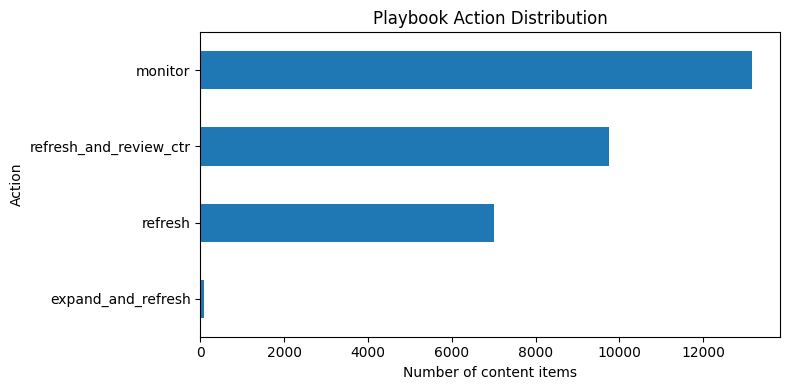

Figure saved to: work/figures/action_playbook_distribution.png


In [29]:
import matplotlib.pyplot as plt

action_counts = (
    playbook_queue["playbook_action"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4))
action_counts.plot(kind="barh")
plt.xlabel("Number of content items")
plt.ylabel("Action")
plt.title("Playbook Action Distribution")
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)

figure_path = "work/figures/action_playbook_distribution.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)

In [30]:
import json

metrics_receipt = {
    "week5_original_client_holdout_precision_at_50": 0.76,
    "week6_row_level_precision_at_50": 0.90,
    "week6_client_grouped_precision_at_50": 0.40,
    "client_grouped_client_overlap": 0,
    "interpretation": "Client-grouped validation is treated as the more cautious estimate for unseen-client performance."
}

with open(
    "work/outputs/w07_validation_receipt.json",
    "w"
) as f:
    json.dump(metrics_receipt, f, indent=2)

print("Validation receipt saved.")

Validation receipt saved.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.